In [1]:
# Imports and Setup
import numpy as np
import matplotlib.pyplot as plt

from causal_gym.envs.cartpole_wind import CartPoleWindPCH

# Helper function to display frames
def display_frames(frames, title="Frames"):
    if not frames:
        print(f"{title}: No frames to display.")
        return
    fig, axes = plt.subplots(1, len(frames), figsize=(len(frames) * 3, 3))
    if len(frames) == 1:
        axes = [axes] # Make it iterable for single frame
    for i, frame in enumerate(frames):
        axes[i].imshow(frame)
        axes[i].axis('off')
        axes[i].set_title(f"Step {i}")
    fig.suptitle(title)
    plt.show()


--- Testing with No Wind ---
Initial observation: [ 0.01823519 -0.0446179   0.         -0.03156282]
Initial wind (from SCM internal): 0.0000
Step 1: Action=1, Obs=[ 0.02  0.15 -0.   -0.32], Reward=1.00, Term=False, Trunc=False
Step 2: Action=0, Obs=[ 0.02 -0.04 -0.01 -0.03], Reward=1.00, Term=False, Trunc=False
Step 3: Action=0, Obs=[ 0.02 -0.24 -0.01  0.26], Reward=1.00, Term=False, Trunc=False
Step 4: Action=1, Obs=[ 0.01 -0.04 -0.   -0.04], Reward=1.00, Term=False, Trunc=False
Step 5: Action=1, Obs=[ 0.01  0.15 -0.   -0.33], Reward=1.00, Term=False, Trunc=False


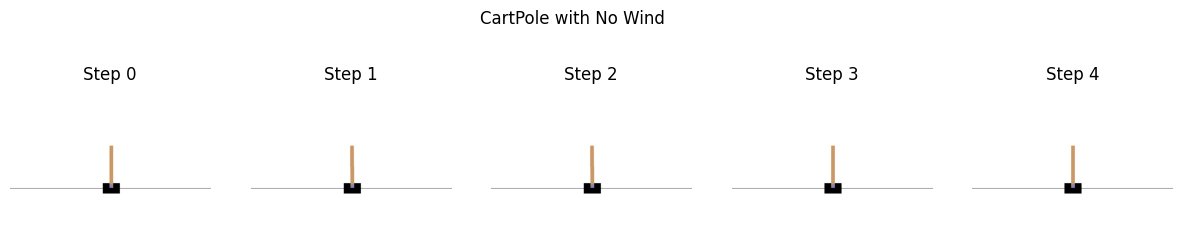

In [2]:
# Test with No Wind
print("\n--- Testing with No Wind ---")

# Instantiate with wind parameters set to zero
env_no_wind = CartPoleWindPCH(wind_mean=0.0, wind_std=0.0, render_mode='rgb_array')
obs, info = env_no_wind.reset(seed=123)
print(f"Initial observation: {obs}")
# Accessing SCM's current_wind. It should be 0.0 as mean and std are 0.
print(f"Initial wind (from SCM internal): {env_no_wind.env.current_wind:.4f}")

frames_no_wind = []
num_steps_test_no_wind = 5

for step in range(num_steps_test_no_wind):
    action = env_no_wind.action_space.sample() # Take random actions
    # Use env.do() for PCH to apply action
    obs, reward, terminated, truncated, info = env_no_wind.do(action)
    frame = env_no_wind.render()
    if frame is not None:
        frames_no_wind.append(frame)
    
    print(f"Step {step+1}: Action={action}, Obs={np.round(obs,2)}, Reward={reward:.2f}, Term={terminated}, Trunc={truncated}")
    if terminated or truncated:
        print("Episode finished.")
        break

env_no_wind.close()
display_frames(frames_no_wind, title="CartPole with No Wind")

--- Testing with Default Wind ---
Initial observation: [ 0.0273956  -0.00611216  0.          0.0197368 ]
Initial wind (from SCM internal): 0.0030
Step 1: Action=1, Obs=[ 0.03  0.19  0.   -0.27], Reward=1.00, Term=False, Trunc=False
Step 2: Action=1, Obs=[ 0.03  0.39 -0.01 -0.57], Reward=1.00, Term=False, Trunc=False
Step 3: Action=1, Obs=[ 0.04  0.6  -0.02 -0.86], Reward=1.00, Term=False, Trunc=False
Step 4: Action=0, Obs=[ 0.05  0.38 -0.03 -0.57], Reward=1.00, Term=False, Trunc=False
Step 5: Action=0, Obs=[ 0.06  0.18 -0.05 -0.29], Reward=1.00, Term=False, Trunc=False


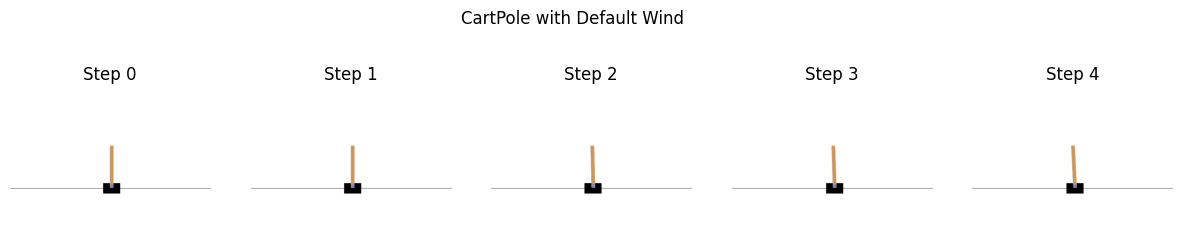

In [3]:
# Test with Default Wind Settings
print("--- Testing with Default Wind ---")

# Default wind_std is 0.01 in CartPoleWindSCM
env_default_wind = CartPoleWindPCH(render_mode='rgb_array')
obs, info = env_default_wind.reset(seed=42)
print(f"Initial observation: {obs}")
print(f"Initial wind (from SCM internal): {env_default_wind.env.current_wind:.4f}") # Accessing SCM's current_wind

frames_default_wind = []
num_steps_test = 5

for step in range(num_steps_test):
    action = env_default_wind.action_space.sample() # Take random actions
    obs, reward, terminated, truncated, info = env_default_wind.do(action)
    frame = env_default_wind.render()
    if frame is not None:
        frames_default_wind.append(frame)
    
    print(f"Step {step+1}: Action={action}, Obs={np.round(obs,2)}, Reward={reward:.2f}, Term={terminated}, Trunc={truncated}")
    if terminated or truncated:
        print("Episode finished.")
        break

env_default_wind.close()
display_frames(frames_default_wind, title="CartPole with Default Wind")


--- Testing with Heavy Wind ---
Initial observation: [-0.04084033 -0.0285856   0.         -0.03327109]
Initial wind (from SCM internal): 0.1066
Step 1: Action=0, Obs=[-0.04 -0.12 -0.    0.26], Reward=1.00, Term=False, Trunc=False
Step 2: Action=0, Obs=[-0.04 -0.21  0.    0.55], Reward=1.00, Term=False, Trunc=False
Step 3: Action=1, Obs=[-0.04  0.09  0.02  0.26], Reward=1.00, Term=False, Trunc=False
Step 4: Action=1, Obs=[-0.04  0.38  0.02 -0.03], Reward=1.00, Term=False, Trunc=False
Step 5: Action=0, Obs=[-0.03  0.3   0.02  0.27], Reward=1.00, Term=False, Trunc=False
Step 6: Action=0, Obs=[-0.02  0.22  0.03  0.57], Reward=1.00, Term=False, Trunc=False
Step 7: Action=0, Obs=[-0.01  0.13  0.04  0.87], Reward=1.00, Term=False, Trunc=False
Step 8: Action=1, Obs=[-0.01  0.43  0.05  0.59], Reward=1.00, Term=False, Trunc=False
Step 9: Action=0, Obs=[0.   0.35 0.07 0.9 ], Reward=1.00, Term=False, Trunc=False
Step 10: Action=0, Obs=[0.01 0.24 0.08 1.21], Reward=1.00, Term=False, Trunc=False
St

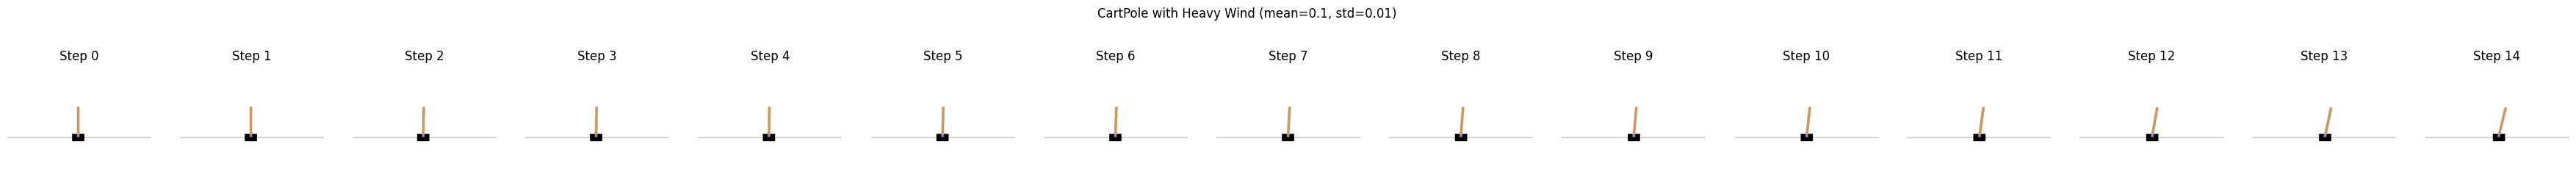

In [4]:
# Test with Heavy Wind
print("\n--- Testing with Heavy Wind ---")

# Instantiate with a stronger wind effect
# Option 1: Strong consistent wind in one direction
env_heavy_wind = CartPoleWindPCH(wind_mean=0.1, wind_std=0.01, render_mode='rgb_array') 
# Option 2: More variable strong wind (could also try higher std like 0.1 or 0.2)
# env_heavy_wind = CartPoleWindPCH(wind_mean=0.0, wind_std=0.2, render_mode='rgb_array')

obs, info = env_heavy_wind.reset(seed=789)
print(f"Initial observation: {obs}")
print(f"Initial wind (from SCM internal): {env_heavy_wind.env.current_wind:.4f}")

frames_heavy_wind = []
num_steps_test_heavy = 15 # More steps to see the effect

for step in range(num_steps_test_heavy):
    action = env_heavy_wind.action_space.sample() # Try random actions, or a fixed one e.g., action = 0
    obs, reward, terminated, truncated, info = env_heavy_wind.do(action)
    frame = env_heavy_wind.render()
    if frame is not None:
        frames_heavy_wind.append(frame)
    
    print(f"Step {step+1}: Action={action}, Obs={np.round(obs,2)}, Reward={reward:.2f}, Term={terminated}, Trunc={truncated}")
    if terminated or truncated:
        print("Episode finished.")
        break

env_heavy_wind.close()
display_frames(frames_heavy_wind, title=f"CartPole with Heavy Wind (mean={env_heavy_wind.env.wind_mean}, std={env_heavy_wind.env.wind_std})")


--- Testing with Initial Pole Angle Offset ---
Initial observation: [0.01587667 0.04083084 0.15421844 0.02254102]
Pole angle from initial obs: 0.1542 radians (8.84 degrees)
Initial wind (from SCM internal): -0.0007
Running for 30 steps to observe pole fall...
Step  1: Action=1, Obs=[ 0.02  0.23  0.15 -0.22], PoleAngle=0.155 rad (8.9 deg), Reward=1.00, Term=False, Trunc=False
Step  2: Action=0, Obs=[0.02 0.03 0.15 0.12], PoleAngle=0.150 rad (8.6 deg), Reward=1.00, Term=False, Trunc=False
Step  3: Action=0, Obs=[ 0.02 -0.16  0.15  0.46], PoleAngle=0.153 rad (8.7 deg), Reward=1.00, Term=False, Trunc=False
Step  4: Action=0, Obs=[ 0.02 -0.36  0.16  0.79], PoleAngle=0.162 rad (9.3 deg), Reward=1.00, Term=False, Trunc=False
Step  5: Action=0, Obs=[ 0.01 -0.56  0.18  1.13], PoleAngle=0.178 rad (10.2 deg), Reward=1.00, Term=False, Trunc=False
Step  6: Action=1, Obs=[ 0.   -0.37  0.2   0.9 ], PoleAngle=0.200 rad (11.5 deg), Reward=1.00, Term=False, Trunc=False
Step  7: Action=0, Obs=[-0.01 -0.

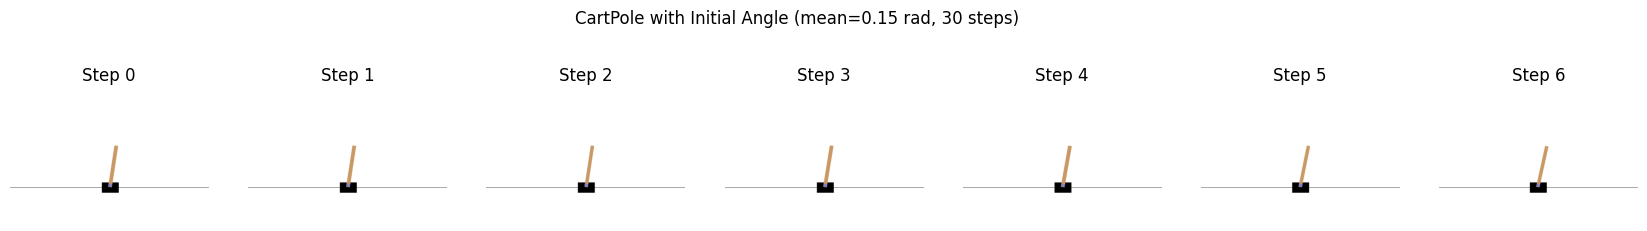

In [5]:
# Test with Initial Pole Angle Offset
print("\n--- Testing with Initial Pole Angle Offset ---")

# Instantiate with a non-zero initial pole angle (e.g., 0.15 radians ~ 8.6 degrees)
# Keep wind minimal for this test to isolate angle effect.
initial_angle_rad = 0.15
env_angled_start = CartPoleWindPCH(
    init_theta_mean=initial_angle_rad, 
    init_theta_std=0.01, # Small std around the mean for consistency, results in angle ~0.15
    wind_mean=0.0,       # Minimal wind
    wind_std=0.001,      # Minimal wind
    render_mode='rgb_array'
)

obs, info = env_angled_start.reset(seed=321)
print(f"Initial observation: {obs}") # obs[2] should be close to initial_angle_rad
print(f"Pole angle from initial obs: {obs[2]:.4f} radians ({np.degrees(obs[2]):.2f} degrees)")
print(f"Initial wind (from SCM internal): {env_angled_start.env.current_wind:.4f}")

frames_angled_start = []
num_steps_test_angled = 30 # Increased from 10 to 30 steps

print(f"Running for {num_steps_test_angled} steps to observe pole fall...")

for step in range(num_steps_test_angled):
    action = env_angled_start.action_space.sample() 
    # To see a more consistent fall, you could try a fixed action, e.g., action = 0 or 1
    # For now, let's stick to random actions.
    obs, reward, terminated, truncated, info = env_angled_start.do(action)
    frame = env_angled_start.render()
    if frame is not None:
        frames_angled_start.append(frame)
    
    print(f"Step {step+1:2d}: Action={action}, Obs={np.round(obs,2)}, PoleAngle={obs[2]:.3f} rad ({np.degrees(obs[2]):.1f} deg), Reward={reward:.2f}, Term={terminated}, Trunc={truncated}")
    if terminated or truncated:
        print("Episode finished.")
        break

env_angled_start.close()
display_frames(frames_angled_start, title=f"CartPole with Initial Angle (mean={initial_angle_rad:.2f} rad, {num_steps_test_angled} steps)")